### `bias_spectroscopic`
------------------------

Short notebook to provide insights on propagated error measurements for bias fits.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

from scipy.optimize import curve_fit
from pathlib import Path

import src.analysis.plots as plots
import src.statistics.corrfiles as cf

tracers = ["BGS_BRIGHT-21.35", "LRG", "ELGnotqso", "ELG_LOPnotqso", "QSO"]
cmap = plt.get_cmap("plasma")
tracer_to_color = {
    tracer: cmap((i + 1) / (len(tracers) + 1)) for i, tracer in enumerate(tracers)
}

DESI_ROOT_DR2 = Path(
    "/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP"
)
PAPER_FIGURES_ROOT = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/"
)

pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

dir_bias = Path(cf.get_base_dir()) / "data" / "bias"
files = {tracer: dir_bias / f"{tracer}_bias.txt" for tracer in tracers}


def load_bias_file(file):
    data = np.loadtxt(file, comments="#")
    return {
        "zmin": data[:, 0],
        "zmax": data[:, 1],
        "zeff": data[:, 2],
        "b": data[:, 3],
        "b_err": data[:, 4],
    }


def bias(z, a, b):  # Laurent et al. 2016 functional form
    return a * (1 + z) ** 2 + b


BGS_BRIGHT-21.35 uncertainty:
  analytical σ: 0.0306
  MC σ: 0.0305
  max diff: 0.0007
BGS_BRIGHT-21.35 fit parameters:
  a = 0.6065 ± 0.0729
  b = 0.5228 ± 0.1289
  χ²/dof = 0.59

LRG uncertainty:
  analytical σ: 0.0206
  MC σ: 0.0207
  max diff: 0.0002
LRG fit parameters:
  a = 0.2355 ± 0.0189
  b = 1.3459 ± 0.0577
  χ²/dof = 1.39

ELGnotqso uncertainty:
  analytical σ: 0.0167
  MC σ: 0.0167
  max diff: 0.0005
ELGnotqso fit parameters:
  a = 0.1549 ± 0.0120
  b = 0.5946 ± 0.0565
  χ²/dof = 0.82

ELG_LOPnotqso uncertainty:
  analytical σ: 0.0172
  MC σ: 0.0173
  max diff: 0.0007
ELG_LOPnotqso fit parameters:
  a = 0.1507 ± 0.0124
  b = 0.5946 ± 0.0588
  χ²/dof = 1.53

QSO uncertainty:
  analytical σ: 0.0420
  MC σ: 0.0416
  max diff: 0.0007
QSO fit parameters:
  a = 0.2521 ± 0.0080
  b = 0.7102 ± 0.0577
  χ²/dof = 1.62


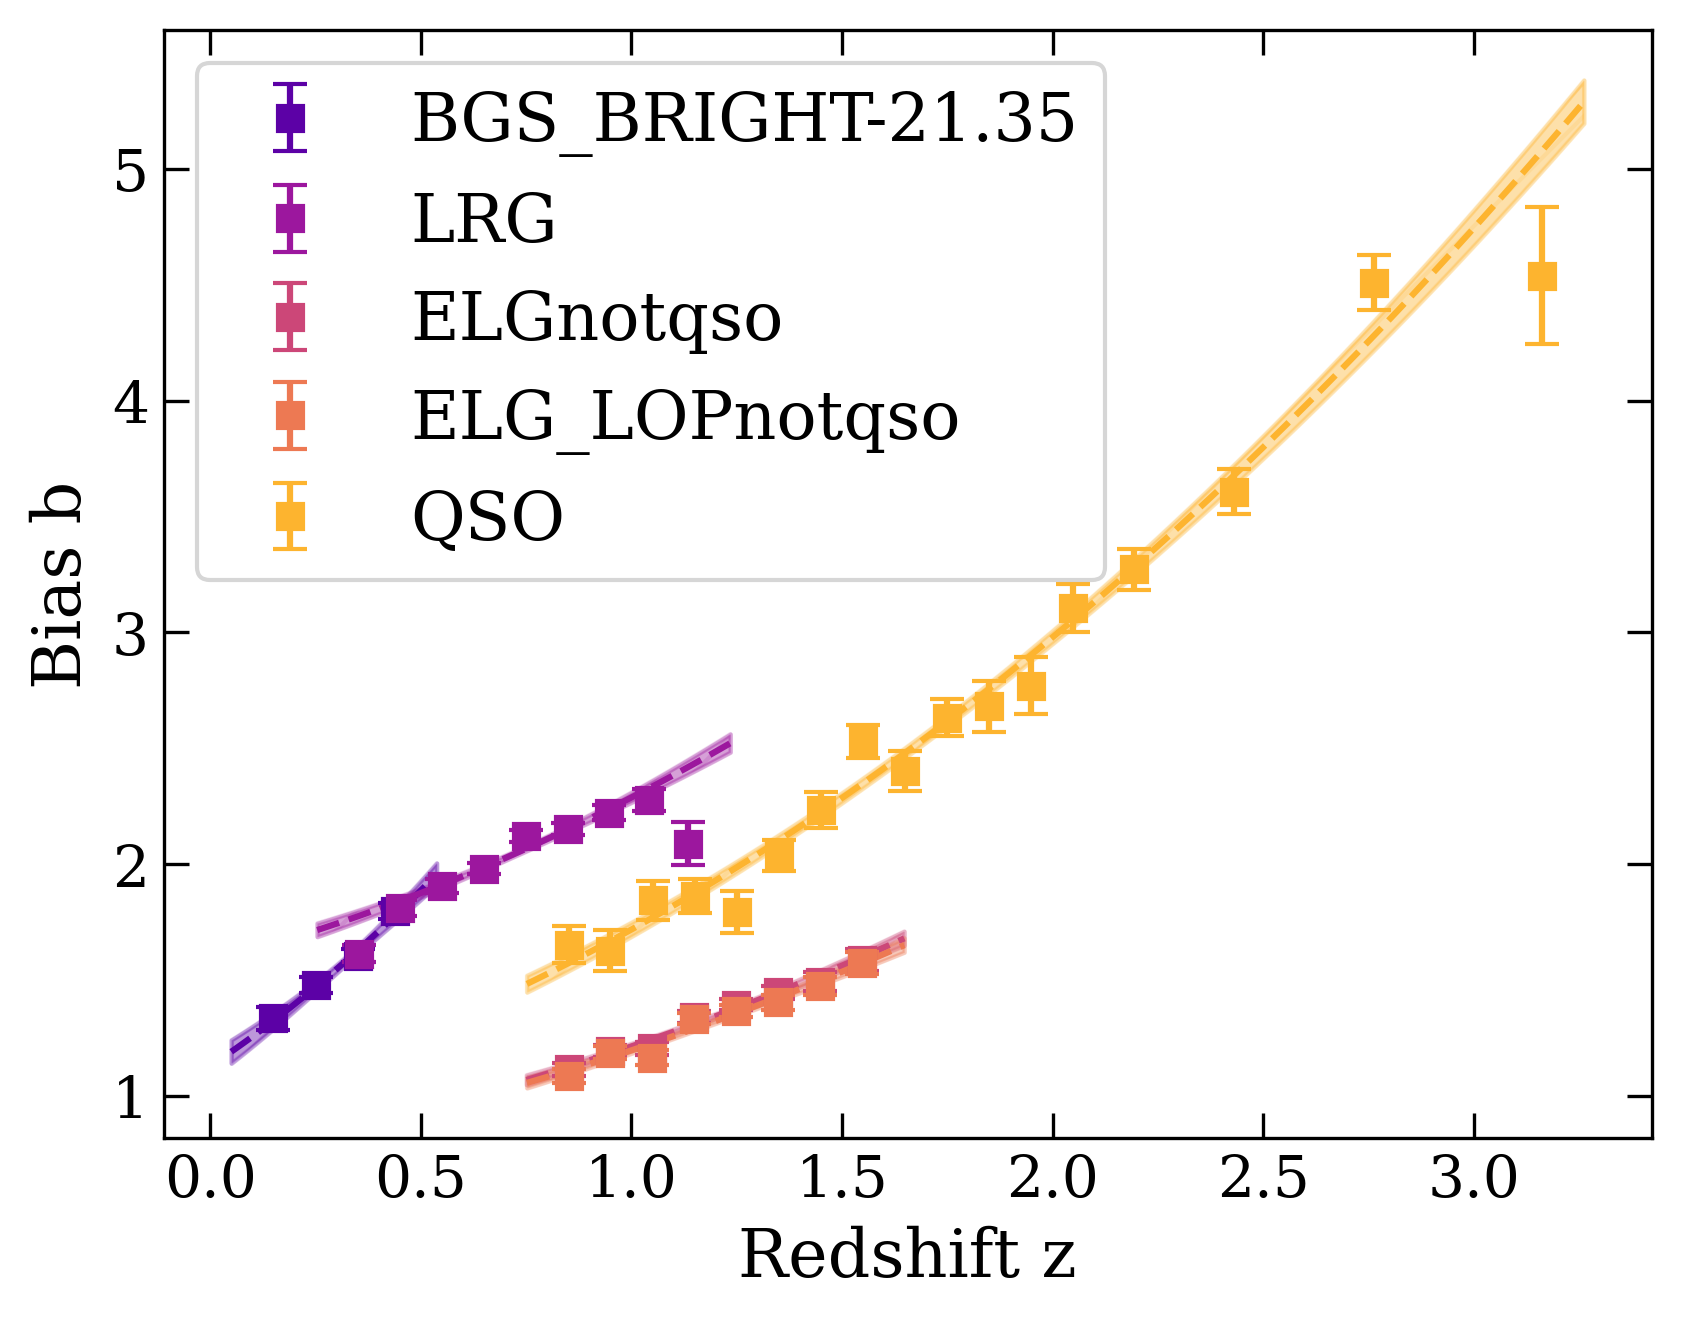

In [ ]:
for tracer in tracers:
    bias_data = load_bias_file(files[tracer])
    plt.errorbar(
        x=bias_data["zeff"],
        y=bias_data["b"],
        yerr=bias_data["b_err"],
        label=tracer,
        color=tracer_to_color[tracer],
        marker="s",
        linestyle="None",
        capsize=4,
    )

    if tracer == "LRG":
        mask = (bias_data["zeff"] > 0.4) & (bias_data["zeff"] < 1.1)
    else:
        mask = np.ones_like(bias_data["zeff"], dtype=bool)

    bias_zeff = bias_data["zeff"][mask]
    bias_b = bias_data["b"][mask]
    bias_b_err = bias_data["b_err"][mask]

    # fit
    popt, pcov = curve_fit(
        bias, bias_zeff, bias_b, sigma=bias_b_err, absolute_sigma=True
    )
    perr = np.sqrt(np.diag(pcov))

    # chi²
    residuals = bias_b - bias(bias_zeff, *popt)
    chi2 = np.sum((residuals / bias_b_err) ** 2)
    ndof = len(bias_zeff) - len(popt)
    chi2_red = chi2 / ndof

    # fit line
    z_fit = np.linspace(min(bias_data["zeff"]) - 0.1, max(bias_data["zeff"]) + 0.1, 100)
    b_fit = bias(z_fit, *popt)

    # Method 1: Analytical (Jacobian)
    J = np.column_stack([(1 + z_fit) ** 2, np.ones_like(z_fit)])
    b_fit_var = np.einsum("ij,jk,ik->i", J, pcov, J)
    b_fit_err_analytical = np.sqrt(b_fit_var)

    # Method 2: Monte Carlo sampling
    params = np.random.multivariate_normal(popt, pcov, 2000)
    b_fit_samples = np.array([bias(z_fit, *pp) for pp in params])
    b_fit_err_mc = np.std(b_fit_samples, axis=0)

    # Plot both uncertainty bands
    plt.plot(z_fit, b_fit, color=tracer_to_color[tracer], linestyle="--")

    # Analytical uncertainty (solid fill)
    plt.fill_between(
        z_fit,
        b_fit - b_fit_err_analytical,
        b_fit + b_fit_err_analytical,
        color=tracer_to_color[tracer],
        alpha=0.3,
    )

    # Monte Carlo uncertainty (hatched or lighter)
    plt.fill_between(
        z_fit,
        b_fit - b_fit_err_mc,
        b_fit + b_fit_err_mc,
        color=tracer_to_color[tracer],
        alpha=0.15,
        edgecolor=tracer_to_color[tracer],
        hatch="///",
    )

    # Compare the uncertainties
    print(f"%\n{tracer} uncertainty:")
    print(f"%  analytical σ: {np.mean(b_fit_err_analytical):.4f}")
    print(f"%  MC σ: {np.mean(b_fit_err_mc):.4f}")
    print(f"%  max diff: {np.max(np.abs(b_fit_err_analytical - b_fit_err_mc)):.4f}")

    ## error on parameters
    print(f"%{tracer} fit parameters:")
    print(f"%  a = {popt[0]:.4f} ± {perr[0]:.4f}")
    print(f"%  b = {popt[1]:.4f} ± {perr[1]:.4f}")
    print(f"%  χ²/dof = {chi2_red:.2f}")

plt.grid()
plt.xlabel("Redshift z", fontsize=16)
plt.ylabel("Bias b", fontsize=16)
plt.legend(loc="upper left", fontsize=16)